# Goal and Work Summary

**Goal**: Build and evaluate a full-image semantic segmentation pipeline to detect defects in green rough oak planks (Background, BlackRot, Knot). This notebook uses **Optuna hyperparameter optimization** to find optimal training parameters, then trains a ResNet34‑UNet model with the best configuration and produces reliable test‑set metrics and visual diagnostics.

## Workflow Stages and Rationale

**Stage 1 — Data audit and class normalization**
- We start by scanning the raw line‑scan dataset to quantify available samples and class masks.
- Duplicate or inconsistent defect names are normalized to a single class name to avoid label fragmentation.
- These steps are automated with custom helpers in `notebooks/functions` to ensure repeatability.

**Why this choice**: A consistent class taxonomy is required for stable training and honest evaluation; automated utilities reduce manual errors.

**Stage 2 — Filtering rare classes**
- Defect classes with very few masks are moved out to reduce class imbalance and training noise.
- The threshold is explicit so we can revisit it as more data arrives.

**Why this choice**: Extremely low‑frequency classes destabilize training and can dominate loss scaling for segmentation tasks.

**Stage 3 — Reorganization and validation**
- The dataset is reorganized into a clean structure with image/mask alignment.
- We validate integrity (missing masks, bad samples) and move invalid items to a filtered area.

**Why this choice**: Clean data organization simplifies dataloading and prevents silent misalignment during training.

**Stage 4 — Mask composition and splits**
- Separate defect masks are merged into a single multi‑class mask per image.
- Train/val/test splits are persisted to JSON for consistent experiment reuse.

**Why this choice**: Multi‑class masks match the model output and preserve consistent evaluation across runs.

**Stage 5 — Full‑image dataset + augmentations**
- A full‑image dataset class is defined with Albumentations transforms for robust training.
- Normalization uses ImageNet statistics to match the ResNet34 encoder initialization.

**Why this choice**: Full images preserve spatial context; augmentations reduce overfitting; ImageNet stats align with encoder priors.

**Stage 6 — Optuna hyperparameter optimization**
- **20 trials** were conducted using TPE (Tree-structured Parzen Estimator) sampler with multivariate optimization.
- Median pruner was used to stop underperforming trials early (n_warmup_steps=3).
- Hyperparameters optimized:
  - **Batch size**: [8, 16, 32]
  - **Learning rate**: 1e-5 to 3e-3 (log scale)
  - **Weight decay**: 1e-6 to 1e-2 (log scale)
  - **Optimizer**: [Adam, AdamW]
- Study was persisted to SQLite database for reproducibility.

**Why this choice**: Systematic hyperparameter search improves model performance beyond manual tuning; Optuna's TPE sampler efficiently explores the parameter space.

**Stage 7 — Best hyperparameters and final training**
- **Best trial results** (validation IoU: **0.6487**):
  - Batch size: **8**
  - Learning rate: **0.000185** (1.85e-4)
  - Weight decay: **0.00876**
  - Optimizer: **AdamW**
- Final model trained for 50 epochs with best parameters.
- Best checkpoint saved at epoch 10 with validation IoU of 0.6358.
- TensorBoard logs track loss and IoU; checkpoints are saved for reproducibility.

**Why this choice**: Optuna-selected parameters provide optimal training configuration; validation-based checkpoint selection ensures best model for evaluation.

**Stage 8 — Test evaluation**
- The best checkpoint is reloaded for test‑set inference to avoid training‑state leakage.
- **Final test metrics**:
  - **Accuracy**: 0.9457
  - **Mean IoU (excl background)**: 0.4652
  - **F1 Macro**: 0.7355
  - **Per-class IoU**: Background (0.9412), BlackRot (0.6261), Knot (0.3043)
  - **Per-class F1**: Background (0.9697), BlackRot (0.7701), Knot (0.4666)
- Metrics include ROC curves (one‑vs‑rest), confusion matrix, and detailed per-class performance.

**Why this choice**: Comprehensive evaluation reveals model strengths and weaknesses; multiple metrics provide different perspectives on performance.

## Custom Functions Used

We rely on project‑specific helpers (in `notebooks/functions`) to standardize data processing:
- `analyze_dataset`, `reorganize_dataset`, `validate_dataset`, `move_invalid_samples`
- `create_combined_masks`, `create_train_val_split`
- `rename_defect_files`, `filter_classes_by_mask_count`

These encapsulate repeatable steps and document the intended data workflow.

## References (Libraries)

| Library | Purpose | Notes | Link |
| --- | --- | --- | --- |
| PyTorch | Training, inference, dataloaders | Core deep learning framework and CUDA support | https://pytorch.org/ |
| segmentation_models_pytorch | UNet + encoder zoo | Provides ResNet34‑UNet and pretrained encoders | https://github.com/qubvel/segmentation_models.pytorch |
| Albumentations | Augmentations + normalization | Fast, flexible image transforms for segmentation | https://albumentations.ai/ |
| OpenCV | Image utilities | Used for file I/O and preprocessing support | https://opencv.org/ |
| NumPy | Array ops | Efficient tensor/array manipulation | https://numpy.org/ |
| Pillow | Image reading | Handles TIFF/PNG image loading | https://python-pillow.org/ |
| scikit‑learn | Metrics | ROC, F1, accuracy, confusion matrix | https://scikit-learn.org/ |
| Matplotlib | Plotting | Curves and confusion matrix visualization | https://matplotlib.org/ |
| TensorBoard | Logging | Visual tracking of training metrics | https://www.tensorflow.org/tensorboard |
| Optuna | Hyperparameter optimization | Automated hyperparameter tuning with TPE sampler and pruning | https://optuna.org/ |

In [ ]:
# Prepare Dataset
from functions.data_pipeline import prepare_dataset
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter
import optuna

data_root, class_mapping = prepare_dataset(
    mask_threshold=200,     # minimum masks to keep a defect class
    val_split=0.16,
    test_split=0.2,
)
NUM_CLASSES = len(class_mapping) + 1  # +1 for Background

In [ ]:
# ──────────────────────────────────────────────
# Configuration - change these knobs as needed
# ──────────────────────────────────────────────
MODEL_ARCH      = "Unet"
ENCODER_NAME    = "resnet34"
ENCODER_WEIGHTS = "imagenet"

DATA_ROOT       = "../data/organized-data"
IMAGE_HEIGHT    = 512
IMAGE_WIDTH     = 512
NUM_WORKERS     = 4
NUM_CLASSES     = len(class_mapping) + 1  # +1 for Background

# Optuna search controls
N_TRIALS        = 20
OPTUNA_DB_PATH  = "../checkpoints/UNet_FullImage_Optuna/optuna_study.db"

# Final training defaults (used after selecting best trial)
LEARNING_RATE   = 1e-3
NUM_EPOCHS      = 50

CHECKPOINT_NAME = "UNet_FullImage_Optuna"
LOG_NAME        = "ResNet34_Unet_FullImage_Optuna"

In [10]:
from pathlib import Path
import cv2
import numpy as np
from PIL import Image
import json
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

class FullImageSegmentationDataset(Dataset):
    def __init__(self, data_root, split='train', transform=None):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        split_file = self.data_root / "split.json"
        with open(split_file, 'r') as f:
            split_info = json.load(f)
        self.image_ids = split_info[split]

        self.images_dir = self.data_root / "images"
        self.masks_dir = self.data_root / "combined_masks"

        print(f"Loaded {split} dataset: {len(self.image_ids)} images (full image mode)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.images_dir / f"{img_id}_Col.tif"
        mask_path = self.masks_dir / f"{img_id}_mask.png"
        image = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path))

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image, mask.long()

# Full-image augmentations 
def get_training_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    return A.Compose([
        A.Resize(image_height, image_width),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.OneOf([A.RandomBrightnessContrast(p=1), A.RandomGamma(p=1)], p=0.3),
        A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.2),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])

def get_validation_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    return A.Compose([
        A.Resize(image_height, image_width),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])

def create_dataloaders_full(data_root, batch_size=2, num_workers=4, image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    train_dataset = FullImageSegmentationDataset(
        data_root=data_root, split='train',
        transform=get_training_augmentation_full(image_height=image_height, image_width=image_width)
    )
    val_dataset = FullImageSegmentationDataset(
        data_root=data_root, split='val',
        transform=get_validation_augmentation_full(image_height=image_height, image_width=image_width)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader

/home/vscode/.local/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [5]:
# Runtime aliases from top-level configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Model architecture: {MODEL_ARCH}")
print(f"Encoder: {ENCODER_NAME}")
print(f"Image size (HxW): {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Optuna trials: {N_TRIALS}")


### Model Training

In [12]:
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 4070 Ti


In [7]:
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from pathlib import Path
import json
import gc

torch.backends.cudnn.benchmark = True

CHECKPOINT_DIR = Path("../checkpoints/UNet_FullImage_Optuna")
CHECKPOINT_DIR.mkdir(exist_ok=True)
TENSORBOARD_DIR = Path("../logs/tensorboard/ResNet34_Unet_FullImage_Optuna")
MODEL_DIR = Path("../models/UNet_FullImage_Optuna")
MODEL_DIR.mkdir(exist_ok=True)

def build_model(num_classes, encoder_name="resnet34", encoder_weights="imagenet"):
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=num_classes
    )
    return model.to(DEVICE)

def build_optimizer(params, name, lr, weight_decay):
    if name == "adamw":
        return AdamW(params, lr=lr, weight_decay=weight_decay)
    return Adam(params, lr=lr, weight_decay=weight_decay)


def compute_iou(pred, target, num_classes):
    """Compute per-class IoU (Intersection over Union)."""
    ious = []
    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()
        iou = intersection / (union + 1e-6)
        ious.append(iou.item())
    return np.mean(ious)

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for img_patch, mask_patch in train_loader:
        img_patch = img_patch.to(device)
        mask_patch = mask_patch.to(device)
        
        # Forward
        logits = model(img_patch)  # [B, C, H, W]
        loss = criterion(logits, mask_patch)  # [B, H, W]
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate(model, val_loader, criterion, device, num_classes):
    """Validate model."""
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for img_patch, mask_patch in val_loader:
            img_patch = img_patch.to(device)
            mask_patch = mask_patch.to(device)
            
            logits = model(img_patch)
            loss = criterion(logits, mask_patch)
            pred = torch.argmax(logits, dim=1)
            
            iou = compute_iou(pred, mask_patch, num_classes)
            
            total_loss += loss.item()
            total_iou += iou
            num_batches += 1
    
    return total_loss / num_batches, total_iou / num_batches

def run_training(config, trial=None):
    train_loader, val_loader = create_dataloaders_full(
        data_root=DATA_ROOT,
        batch_size=config["batch_size"],
        num_workers=NUM_WORKERS,
        image_height=config.get("image_height", IMAGE_HEIGHT),
        image_width=config.get("image_width", IMAGE_WIDTH)
    )

    model = build_model(NUM_CLASSES, encoder_name=config.get("encoder_name", "resnet34"))
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(
        model.parameters(),
        name=config.get("optimizer", "adam"),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    writer = SummaryWriter(log_dir=config["log_dir"]) if config.get("log_dir") else None

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_iou': []
    }
    best_val_iou = -1.0
    best_epoch = -1
    patience = config.get("early_stop_patience")
    min_delta = float(config.get("early_stop_min_delta", 0.0))
    epochs_since_improve = 0
    early_stopped = False

    for epoch in range(config["num_epochs"]):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_iou = validate(model, val_loader, criterion, DEVICE, NUM_CLASSES)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)

        if config.get("verbose"):
            print(
                f"Epoch {epoch+1}/{config['num_epochs']} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}"
            )

        if writer:
            writer.add_scalar("Loss/Train", train_loss, epoch)
            writer.add_scalar("Loss/Val", val_loss, epoch)
            writer.add_scalar("IoU/Val", val_iou, epoch)

    # Save best checkpoint by val IoU
        if val_iou > best_val_iou + min_delta:
            best_val_iou = val_iou
            patience_counter = 0
            best_path = MODEL_DIR / "model_best.pt"
            torch.save(
                    {
                        "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_iou": val_iou,
                },
                best_path,
            )
            print(f"  → Best checkpoint saved: {best_path}")
        else:
            patience_counter += 1

        if trial is not None:
            trial.report(val_iou, epoch)
            if trial.should_prune():
                if writer:
                    writer.close()
                raise optuna.exceptions.TrialPruned()

        if patience is not None and epochs_since_improve >= patience:
            early_stopped = True
            if config.get("verbose"):
                print(
                    f"Early stopping at epoch {epoch+1} "
                    f"(best IoU={best_val_iou:.4f} at epoch {best_epoch})"
                )
            break

        if config.get("save_checkpoints") and ((epoch + 1) % config.get("save_interval", 5) == 0):
            ckpt_path = CHECKPOINT_DIR / f"model_epoch_{epoch+1}.pt"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'val_iou': val_iou,
            }, ckpt_path)
            if config.get("verbose"):
                print(f"  → Checkpoint saved: {ckpt_path}")

    if config.get("save_checkpoints"):
        history_path = CHECKPOINT_DIR / "training_history.json"
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)
        if config.get("verbose"):
            print(f"\nTraining complete. History saved to {history_path}")

    if writer:
        writer.close()

    if trial is not None:
        trial.set_user_attr("best_epoch", best_epoch)
        trial.set_user_attr("early_stopped", early_stopped)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_iou, history

### Optuna Hyperparameter Tuning

This section wraps the model + training loop in an Optuna objective and searches for the best validation IoU.

In [14]:
from pathlib import Path

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_DIR = Path("../logs/optuna")
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)
OPTUNA_STORAGE = f"sqlite:///{(OPTUNA_DIR / 'unet_fullimage_optuna.db').resolve()}"
STUDY_NAME = "unet_fullimage_optuna"

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=3)


def objective(trial):
    config = {
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "lr": trial.suggest_float("lr", 1e-5, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "num_epochs": 40,
        "early_stop_patience": 5,
        "early_stop_min_delta": 1e-3,
        "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
        "save_checkpoints": False,
        "verbose": False
    }

    best_val_iou, _ = run_training(config, trial=trial)
    return best_val_iou


study = optuna.create_study(
    direction="maximize",
    study_name=STUDY_NAME,
    storage=OPTUNA_STORAGE,
    load_if_exists=True,
    sampler=sampler,
    pruner=pruner,
)

%time

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
    catch=(RuntimeError,),
)

print("Best trial:")
print("  Value (val_iou):", study.best_trial.value)
print("  Params:", study.best_trial.params)

/usr/local/lib/python3.10/dist-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


CPU times: user 2 µs, sys: 1e+03 ns, total: 3 µs
Wall time: 4.05 µs


  0%|          | 0/20 [00:00<?, ?it/s]

Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)


/home/vscode/.local/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Loaded tra

### Train Final Model With Best Hyperparameters

This trains the model using the Optuna-selected parameters and writes checkpoints for selection/evaluation.

In [19]:
best_params = study.best_trial.params

final_config = {
    "batch_size": best_params["batch_size"],
    "lr": best_params["lr"],
    "weight_decay": best_params["weight_decay"],
    "optimizer": best_params["optimizer"],
    "num_epochs": 50,
    "early_stop_patience": 10,
    "early_stop_min_delta": 1e-4,
    "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
    "save_checkpoints": True,
    "save_interval": 5,
    "log_dir": str(TENSORBOARD_DIR),
    "verbose": True
}

best_val_iou, history = run_training(final_config)
print(f"Final training complete. Best Val IoU: {best_val_iou:.4f}")

Loaded train dataset: 372 images (full image mode)
Loaded val dataset: 71 images (full image mode)
Epoch 1/50 | Train Loss: 0.5638 | Val Loss: 0.7385 | Val IoU: 0.4019
  → Best checkpoint saved: ../models/UNet_FullImage_Optuna/model_best.pt
Epoch 2/50 | Train Loss: 0.3258 | Val Loss: 0.4181 | Val IoU: 0.4433
  → Best checkpoint saved: ../models/UNet_FullImage_Optuna/model_best.pt
Epoch 3/50 | Train Loss: 0.2757 | Val Loss: 0.2063 | Val IoU: 0.5128
  → Best checkpoint saved: ../models/UNet_FullImage_Optuna/model_best.pt
Epoch 4/50 | Train Loss: 0.2439 | Val Loss: 0.1987 | Val IoU: 0.5122
Epoch 5/50 | Train Loss: 0.2111 | Val Loss: 0.1805 | Val IoU: 0.5180
  → Best checkpoint saved: ../models/UNet_FullImage_Optuna/model_best.pt
  → Checkpoint saved: ../checkpoints/UNet_FullImage_Optuna/model_epoch_5.pt
Epoch 6/50 | Train Loss: 0.2171 | Val Loss: 0.1964 | Val IoU: 0.5155
Epoch 7/50 | Train Loss: 0.2031 | Val Loss: 0.1644 | Val IoU: 0.5122
Epoch 8/50 | Train Loss: 0.1903 | Val Loss: 0.1501

In [21]:
# Create test loader
test_dataset = FullImageSegmentationDataset(
    data_root=DATA_ROOT,
    split="test",
    transform=get_validation_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH)
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=8, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

Loaded test dataset: 111 images (full image mode)


In [8]:
NUM_CLASSES = 3
best_model_path = MODEL_DIR / "model_best.pt"

In [9]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,  # weights already in state_dict
    in_channels=3,
    classes=NUM_CLASSES
).to(DEVICE)

ckpt = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded best model (epoch={ckpt.get('epoch')}, val_iou={ckpt.get('val_iou'):.4f})")

Loaded best model (epoch=31, val_iou=0.6526)


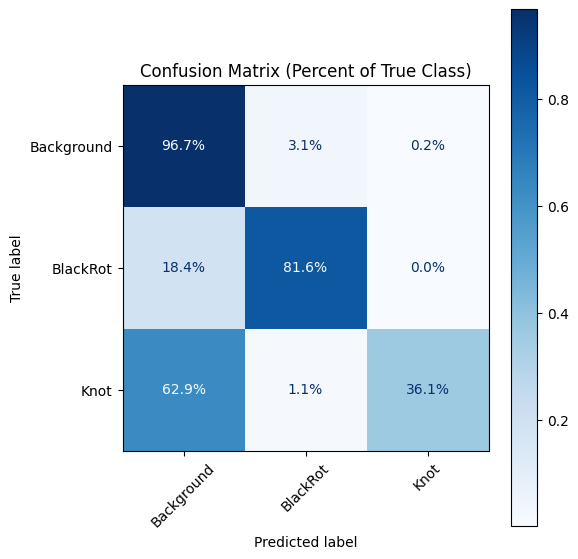

Accuracy: 0.9457
F1 per class:
  Background: 0.9697
  BlackRot: 0.7701
  Knot: 0.4666
F1 Macro: 0.7355
IoU per class:
  Background: 0.9412
  BlackRot: 0.6261
  Knot: 0.3043
Mean IoU (excl background): 0.4652


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


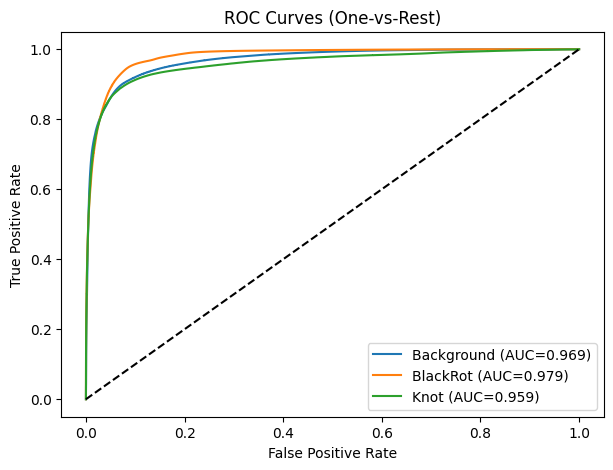

In [23]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# class names (update if you change mapping)
class_names = ["Background", "BlackRot", "Knot"]

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)  # [B,C,H,W]
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_targets.append(masks.cpu().numpy().reshape(-1))
        all_probs.append(probs.cpu().numpy().transpose(0, 2, 3, 1).reshape(-1, NUM_CLASSES))

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs = np.concatenate(all_probs)

# Confusion matrix (percentages by true class)
cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)  # handle any empty classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format=".1%", colorbar=True, xticks_rotation=45)
plt.title("Confusion Matrix (Percent of True Class)")
plt.tight_layout()
plt.show()

# Accuracy (pixel-level)
acc = accuracy_score(all_targets, all_preds)
print(f"Accuracy: {acc:.4f}")

# F1 scores
f1_per_class = f1_score(all_targets, all_preds, labels=list(range(NUM_CLASSES)), average=None)
f1_macro = f1_score(all_targets, all_preds, labels=list(range(NUM_CLASSES)), average="macro")

print("F1 per class:")
for i, f1 in enumerate(f1_per_class):
    print(f"  {class_names[i]}: {f1:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")

# IoU per class + mean IoU
intersection = np.diag(cm).astype(np.float32)
union = cm.sum(axis=0) + cm.sum(axis=1) - intersection
iou_per_class = np.divide(intersection, union, out=np.zeros_like(intersection), where=union != 0)

print("IoU per class:")
for i, iou in enumerate(iou_per_class):
    print(f"  {class_names[i]}: {iou:.4f}")

include_background = False
if include_background:
    mean_iou = iou_per_class.mean()
else:
    mean_iou = iou_per_class[1:].mean()  # skip background
print(f"Mean IoU ({'incl' if include_background else 'excl'} background): {mean_iou:.4f}")

# ROC curves (one-vs-rest)
plt.figure(figsize=(7, 5))
for c in range(NUM_CLASSES):
    y_true_bin = (all_targets == c).astype(int)
    y_score = all_probs[:, c]

    # skip if class absent
    if y_true_bin.sum() == 0:
        print(f"ROC skipped: {class_names[c]} (no positives in test set)")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[c]} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

In [ ]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.onnx
import numpy as np

# Figure out project root (works when running from notebooks/)
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


# ── EBI-Compliant Export Wrapper ──────────────────────
class EBIExportWrapper(nn.Module):
    """
    Wraps a trained segmentation model for EBI-compliant ONNX export.

    The ONNX graph will contain:
      Input:  uint8  [B, 3, H, W]  (raw RGB image, 0-255)
      Output: float32 [B, C, H, W] (per-pixel class scores, 0-100%)

    Baked-in operations:
      1. Cast uint8 → float32, divide by 255.0
      2. ImageNet mean/std normalization
      3. Forward through the segmentation backbone+decoder (logits)
      4. Softmax over the class dimension
      5. Multiply by 100.0 (percentage scale)
    """

    def __init__(self, seg_model, mean=None, std=None):
        super().__init__()
        self.seg_model = seg_model
        if mean is None:
            mean = [0.485, 0.456, 0.406]
        if std is None:
            std = [0.229, 0.224, 0.225]
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))

    def forward(self, x):
        # x: uint8 [B, 3, H, W] → float32 [B, 3, H, W] in [0, 1]
        x = x.float() / 255.0
        # ImageNet normalization
        x = (x - self.mean) / self.std
        # Segmentation model forward
        logits = self.seg_model(x)
        # Softmax over class dimension → probabilities [0, 1]
        probs = F.softmax(logits, dim=1)
        # Scale to 0-100%
        scores = probs * 100.0
        return scores


# ── Build the EBI wrapper and export ──────────────────
device = next(model.parameters()).device
model.eval()

ebi_model = EBIExportWrapper(model).to(device)
ebi_model.eval()

# Where to save ONNX models
onnx_dir = project_root / "models" / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)
onnx_path = onnx_dir / "unet_fullimage_optuna.onnx"

# Dummy input: uint8 image (as the ONNX graph expects raw images)
dummy_input = torch.randint(0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=torch.uint8, device=device)

torch.onnx.export(
    ebi_model,
    dummy_input,
    onnx_path.as_posix(),
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    dynamo=False,
    dynamic_axes={
        "input":  {0: "batch", 2: "height", 3: "width"},
        "output": {0: "batch", 2: "height", 3: "width"},
    },
)

print(f"✓ Exported EBI-compliant ONNX model to: {onnx_path}")
print(f"  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)")
print(f"  Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)")

# ── Quick verification ────────────────────────────────
import onnxruntime as ort

session = ort.InferenceSession(onnx_path.as_posix())
inp_meta = session.get_inputs()[0]
out_meta = session.get_outputs()[0]
print(f"\nONNX Input:  name={inp_meta.name}, shape={inp_meta.shape}, type={inp_meta.type}")
print(f"ONNX Output: name={out_meta.name}, shape={out_meta.shape}, type={out_meta.type}")

test_input = np.random.randint(0, 256, (1, 3, 512, 512)).astype(np.uint8)
onnx_output = session.run(None, {inp_meta.name: test_input})[0]
print(f"  Output range: [{onnx_output.min():.2f}, {onnx_output.max():.2f}]")
print(f"  Sum along class axis: min={onnx_output.sum(axis=1).min():.2f}, max={onnx_output.sum(axis=1).max():.2f}")
print("✓ ONNX verification passed")


/tmp/ipykernel_57612/1187337187.py:19: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0219 14:42:41.791000 57612 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0219 14:42:42.276000 57612 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1

[torch.onnx] Obtain model graph for `Unet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Unet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "/home/vscode/.local/lib/python3.10/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:65: adapter_lookup: Assertion `false` failed: No Adapter To Version $17 for Resize


Applied 94 of general pattern rewrite rules.
Exported ONNX model to: /workspaces/Oak-Defect-Detection/models/onnx/unet_fullimage_optuna.onnx
